<a href="https://colab.research.google.com/github/JSEFERINO/Archivos-DOE-2026/blob/main/Block_Design.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **DISEÑO DE EXPERIMENTOS**

**AUTOR:** DANIEL ANDRES ARIAS LOPEZ

**FECHA:** 11 DE SEPTIEMBRE DE 2026

# EJEMPLO 1: COMPARACIÓN DE MÉTODOS DE ENSAMBLE (DBCA)

--- PROMEDIOS POR MÉTODO ---
Metodo
A     7.50
B     9.00
C    12.75
D    10.75 

--- TABLA ANOVA ---
                         df  sum_sq  mean_sq      F    PR(>F)
Métodos (Tratamientos)  3.0    61.5     20.5  10.25  0.002919
Bloques (Operadores)    3.0    28.5      9.5   4.75  0.029846
Residual (Error)        9.0    18.0      2.0    NaN       NaN 

--- PRUEBA HSD DE TUKEY (α = 0.05) ---
Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj   lower  upper  reject
---------------------------------------------------
     A      B      1.5  0.709 -2.6325 5.6325  False
     A      C     5.25 0.0123  1.1175 9.3825   True
     A      D     3.25 0.1443 -0.8825 7.3825  False
     B      C     3.75 0.0799 -0.3825 7.8825  False
     B      D     1.75 0.6049 -2.3825 5.8825  False
     C      D     -2.0 0.5019 -6.1325 2.1325  False
--------------------------------------------------- 

--- PRUEBA LSD DE FISHER (α = 0.05) ---
Valor crítico LSD: 2.2622

Comparación  | Dif M

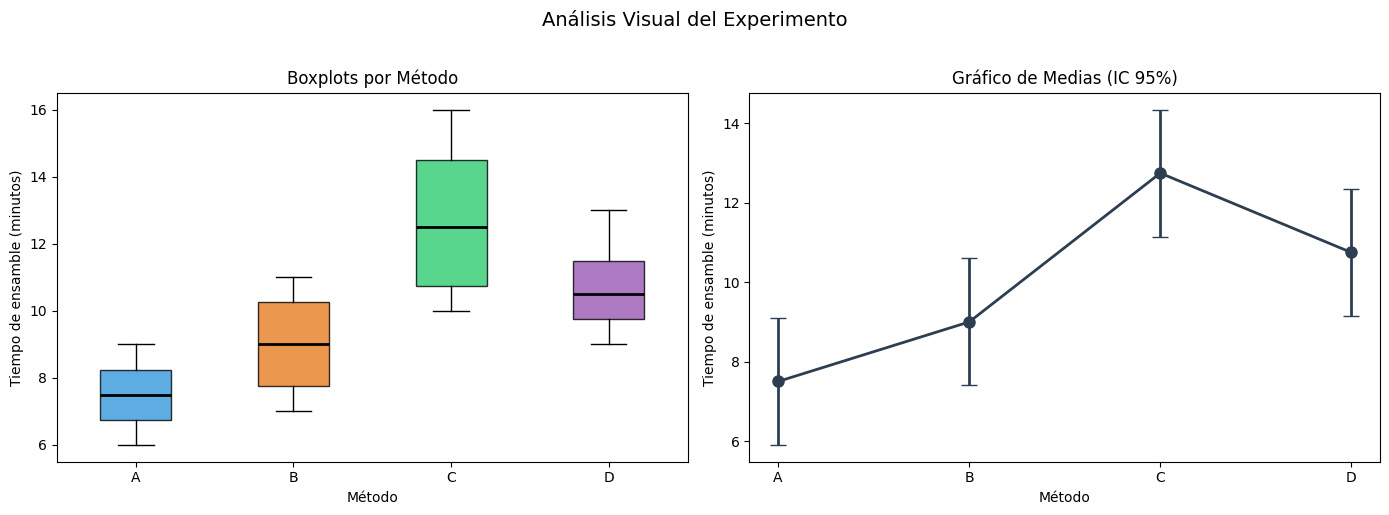

In [ ]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import scipy.stats as stats
import matplotlib.pyplot as plt

# ==========================================
# 1. ENTRADA DE DATOS (Solo edita esta parte)
# ==========================================
# Filas = Operadores (Bloques), Columnas = Métodos (Tratamientos)
datos = np.array([
    [6,  7, 10, 10],  # Operador 1
    [9, 10, 16, 13],  # Operador 2
    [7, 11, 11, 11],  # Operador 3
    [8,  8, 14,  9]   # Operador 4
])

metodos_nombres = ['A', 'B', 'C', 'D']
operadores_nombres = ['Op1', 'Op2', 'Op3', 'Op4']

# ==========================================
# 2. PREPARACIÓN DE LOS DATOS (Formato largo)
# ==========================================
filas, columnas = datos.shape
data_lista = []

for f in range(filas):
    for c in range(columnas):
        data_lista.append({
            'Operador': operadores_nombres[f],
            'Metodo': metodos_nombres[c],
            'Tiempo': datos[f, c]
        })

df = pd.DataFrame(data_lista)

print("--- PROMEDIOS POR MÉTODO ---")
print(df.groupby('Metodo')['Tiempo'].mean().to_string(), "\n")

# ==========================================
# 3. TABLA ANOVA (DBCA)
# ==========================================
modelo = ols('Tiempo ~ C(Metodo) + C(Operador)', data=df).fit()
tabla_anova = sm.stats.anova_lm(modelo, typ=1)

tabla_anova.index = ['Métodos (Tratamientos)', 'Bloques (Operadores)', 'Residual (Error)']
print("--- TABLA ANOVA ---")
print(tabla_anova[['df', 'sum_sq', 'mean_sq', 'F', 'PR(>F)']], "\n")

# ==========================================
# 4. PRUEBAS POST-HOC (Tukey & Fisher LSD)
# ==========================================
gl_error = int(tabla_anova.loc['Residual (Error)', 'df'])
cm_error = tabla_anova.loc['Residual (Error)', 'mean_sq']
n_tratamiento = filas

print("--- PRUEBA HSD DE TUKEY (α = 0.05) ---")
tukey = pairwise_tukeyhsd(endog=df['Tiempo'], groups=df['Metodo'], alpha=0.05)
print(tukey.summary(), "\n")

print("--- PRUEBA LSD DE FISHER (α = 0.05) ---")
t_critico = stats.t.ppf(1 - 0.05/2, df=gl_error)
valor_lsd = t_critico * np.sqrt(2 * cm_error / n_tratamiento)
print(f"Valor crítico LSD: {valor_lsd:.4f}\n")

print(f"{'Comparación':<12} | {'Dif Medias':<10} | {'Estadístico t':<13} | {'Valor-p':<8} | ¿Signif.?")
for i in range(len(metodos_nombres)):
    for j in range(i + 1, len(metodos_nombres)):
        m1, m2 = metodos_nombres[i], metodos_nombres[j]
        media1 = df[df['Metodo'] == m1]['Tiempo'].mean()
        media2 = df[df['Metodo'] == m2]['Tiempo'].mean()
        dif = abs(media1 - media2)

        t_obs = dif / np.sqrt(2 * cm_error / n_tratamiento)
        p_val = 2 * (1 - stats.t.cdf(t_obs, df=gl_error))
        signif = "Sí" if p_val < 0.05 else "No"
        print(f"{m1} - {m2:<9} | {dif:<10.2f} | {t_obs:<13.2f} | {p_val:<8.4f} | {signif}")
print("\n")

# ==========================================
# 5. INTERPRETACIÓN GENERAL AUTOMÁTICA
# ==========================================
print("=========================================================================")
print("12. INTERPRETACIÓN DE PRUEBAS")
print("=========================================================================")
print("🔵 Con la prueba de Tukey (más conservadora):")
print("   solo los pares A-C, A-D y B-C presentan diferencias significativas.")
print("   Las demás comparaciones no muestran diferencias estadísticas concluyentes.\n")

print("🟠 Con la prueba LSD (más sensible):")
print(f"   se detectan diferencias significativas en los mismos pares (A-C, A-D y B-C),")
print(f"   ya que su diferencia de medias supera el valor crítico LSD de {valor_lsd:.3f}.\n")

media_A = df[df['Metodo'] == 'A']['Tiempo'].mean()
print(f"🟢 El método A presenta el menor tiempo promedio de ensamble ({media_A:.2f} minutos),")
print("   por lo que es el método preferible cuando se busca minimizar el tiempo de ensamble.")
print("=========================================================================\n")

# ==========================================
# 6. GRÁFICOS (Boxplots y Gráfico de Medias)
# ==========================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colores_boxplots = ['#3498db', '#e67e22', '#2ecc71', '#9b59b6']
datos_agrupados = [df[df['Metodo'] == m]['Tiempo'].values for m in metodos_nombres]
bp = axes[0].boxplot(datos_agrupados, patch_artist=True)
axes[0].set_xticklabels(metodos_nombres)

for i, box in enumerate(bp['boxes']):
    box.set_facecolor(colores_boxplots[i % len(colores_boxplots)])
    box.set_alpha(0.8)

for median in bp['medians']:
    median.set(color='black', linewidth=2)

axes[0].set_title('Boxplots por Método')
axes[0].set_ylabel('Tiempo de ensamble (minutos)')
axes[0].set_xlabel('Método')

medias = df.groupby('Metodo')['Tiempo'].mean()
error_estandar = np.sqrt(cm_error / n_tratamiento)
intervalo_error = t_critico * error_estandar

axes[1].errorbar(medias.index, medias.values, yerr=intervalo_error, fmt='o-',
                 capsize=6, color='#2c3e50', markersize=8, linewidth=2)
axes[1].set_title('Gráfico de Medias (IC 95%)')
axes[1].set_ylabel('Tiempo de ensamble (minutos)')
axes[1].set_xlabel('Método')

plt.suptitle('Análisis Visual del Experimento', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()


# Ejemplo 2 - DBCA con bloques aleatorios. Evaluación de compuestos para reducir el consumo de gasolina

CÁLCULO DEL DATO PERDIDO (FÓRMULA DE YATES)
Suma tratamiento B (sin perdido) Y*_B : 106.8
Suma bloque 8 (sin perdido)      Y*_8 : 29.9
Suma total (sin perdido)         Y*...: 359.9
Valor estimado imputado (omega)  Y^_8B: 14.35

--- TABLA ANOVA (CORREGIDA: df_error - 1) ---
                             df     sum_sq   mean_sq          F        PR(>F)
Compuestos (Tratamientos)   2.0   4.507222  2.253611  12.377441  6.687379e-04
Vehículos (Bloques)         8.0  38.773333  4.846667  26.619203  1.618653e-07
Residual (Error)           15.0   2.731111  0.182074        NaN           NaN 

--- PRUEBA HSD DE TUKEY (α = 0.05) ---
Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj   lower  upper  reject
---------------------------------------------------
     A      B  -0.2389 0.9217  -1.787 1.3092  False
     A      C   0.7222 0.4849 -0.8259 2.2703  False
     B      C   0.9611 0.2861  -0.587 2.5092  False
--------------------------------------------------- 

--- PRU

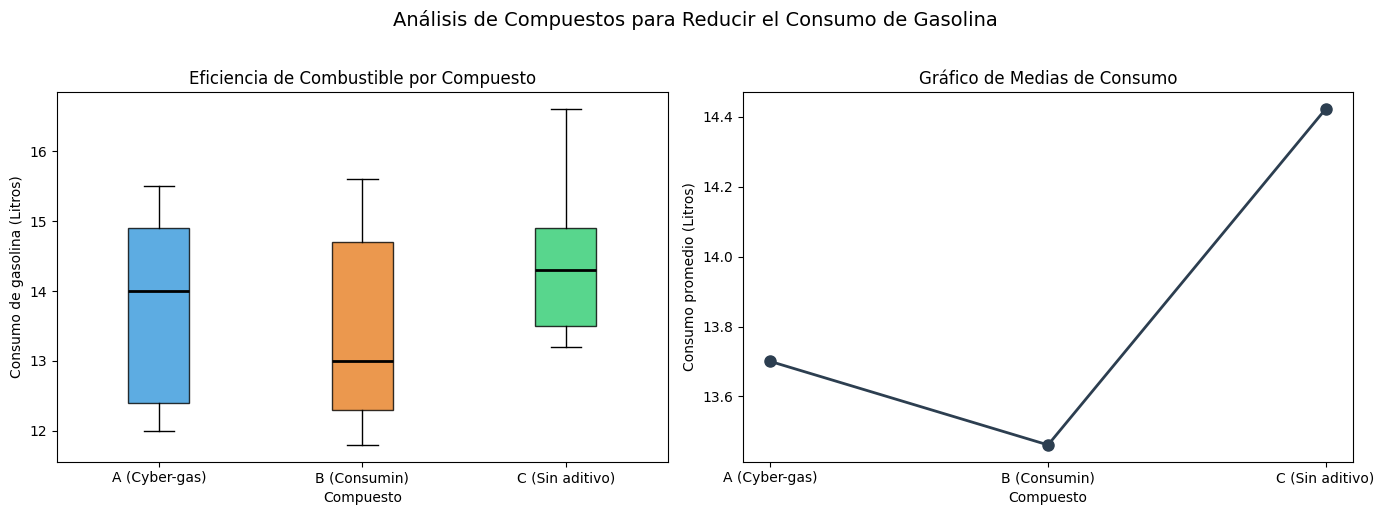

In [ ]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
from statsmodels.formula.api import ols
import scipy.stats as stats
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import matplotlib.pyplot as plt

# ==========================================
# 1. ENTRADA DE DATOS (Con None en el dato perdido)
# ==========================================
datos_experimento = [
    {'Vehiculo': 'V1', 'Compuesto': 'A', 'Consumo': 15.5},
    {'Vehiculo': 'V1', 'Compuesto': 'B', 'Consumo': 15.6},
    {'Vehiculo': 'V1', 'Compuesto': 'C', 'Consumo': 16.6},

    {'Vehiculo': 'V2', 'Compuesto': 'A', 'Consumo': 13.1},
    {'Vehiculo': 'V2', 'Compuesto': 'B', 'Consumo': 13.0},
    {'Vehiculo': 'V2', 'Compuesto': 'C', 'Consumo': 13.5},

    {'Vehiculo': 'V3', 'Compuesto': 'A', 'Consumo': 12.2},
    {'Vehiculo': 'V3', 'Compuesto': 'B', 'Consumo': 11.8},
    {'Vehiculo': 'V3', 'Compuesto': 'C', 'Consumo': 13.4},

    {'Vehiculo': 'V4', 'Compuesto': 'A', 'Consumo': 14.2},
    {'Vehiculo': 'V4', 'Compuesto': 'B', 'Consumo': 15.0},
    {'Vehiculo': 'V4', 'Compuesto': 'C', 'Consumo': 14.8},

    {'Vehiculo': 'V5', 'Compuesto': 'A', 'Consumo': 14.0},
    {'Vehiculo': 'V5', 'Compuesto': 'B', 'Consumo': 12.4},
    {'Vehiculo': 'V5', 'Compuesto': 'C', 'Consumo': 14.3},

    {'Vehiculo': 'V6', 'Compuesto': 'A', 'Consumo': 14.9},
    {'Vehiculo': 'V6', 'Compuesto': 'B', 'Consumo': 14.7},
    {'Vehiculo': 'V6', 'Compuesto': 'C', 'Consumo': 15.6},

    {'Vehiculo': 'V7', 'Compuesto': 'A', 'Consumo': 12.0},
    {'Vehiculo': 'V7', 'Compuesto': 'B', 'Consumo': 12.0},
    {'Vehiculo': 'V7', 'Compuesto': 'C', 'Consumo': 13.2},

    {'Vehiculo': 'V8', 'Compuesto': 'A', 'Consumo': 15.0},
    {'Vehiculo': 'V8', 'Compuesto': 'B', 'Consumo': None},  # <-- DATO PERDIDO
    {'Vehiculo': 'V8', 'Compuesto': 'C', 'Consumo': 14.9},

    {'Vehiculo': 'V9', 'Compuesto': 'A', 'Consumo': 12.4},
    {'Vehiculo': 'V9', 'Compuesto': 'B', 'Consumo': 12.3},
    {'Vehiculo': 'V9', 'Compuesto': 'C', 'Consumo': 13.5}
]

df_inicial = pd.DataFrame(datos_experimento)
compuestos_nombres = ['A', 'B', 'C']

# ==========================================
# 2. CÁLCULO FORMAL DE LA FÓRMULA DE YATES
# ==========================================
k = 3  # Número de tratamientos (compuestos)
b = 9  # Número de bloques (vehículos)

Y_B_star = df_inicial[df_inicial['Compuesto'] == 'B']['Consumo'].sum()
Y_8_star = df_inicial[df_inicial['Vehiculo'] == 'V8']['Consumo'].sum()
Y_total_star = df_inicial['Consumo'].sum()

# Fórmula expuesta en la imagen de referencia
omega = (k * Y_B_star + b * Y_8_star - Y_total_star) / ((k - 1) * (b - 1))

print("=========================================================================")
print("CÁLCULO DEL DATO PERDIDO (FÓRMULA DE YATES)")
print("=========================================================================")
print(f"Suma tratamiento B (sin perdido) Y*_B : {Y_B_star:.1f}")
print(f"Suma bloque 8 (sin perdido)      Y*_8 : {Y_8_star:.1f}")
print(f"Suma total (sin perdido)         Y*...: {Y_total_star:.1f}")
print(f"Valor estimado imputado (omega)  Y^_8B: {omega:.2f}\n")

df = df_inicial.copy()
df.loc[df['Consumo'].isna(), 'Consumo'] = omega

# ==========================================
# 3. TABLA ANOVA AJUSTADA POR DATO PERDIDO
# ==========================================
modelo = ols('Consumo ~ C(Compuesto) + C(Vehiculo)', data=df).fit()
tabla_anova = sm.stats.anova_lm(modelo, typ=1)

tabla_anova.index = ['Compuestos (Tratamientos)', 'Vehículos (Bloques)', 'Residual (Error)']

# Ajuste metodológico estricto: df_error - 1
tabla_anova.loc['Residual (Error)', 'df'] -= 1
tabla_anova['mean_sq'] = tabla_anova['sum_sq'] / tabla_anova['df']

gl_error = tabla_anova.loc['Residual (Error)', 'df']
cm_error = tabla_anova.loc['Residual (Error)', 'mean_sq']

for f in ['Compuestos (Tratamientos)', 'Vehículos (Bloques)']:
    gl_efecto = tabla_anova.loc[f, 'df']
    tabla_anova.loc[f, 'F'] = tabla_anova.loc[f, 'mean_sq'] / cm_error
    tabla_anova.loc[f, 'PR(>F)'] = 1 - stats.f.cdf(tabla_anova.loc[f, 'F'], gl_efecto, gl_error)

print("--- TABLA ANOVA (CORREGIDA: df_error - 1) ---")
print(tabla_anova[['df', 'sum_sq', 'mean_sq', 'F', 'PR(>F)']], "\n")

# ==========================================
# 4. PRUEBAS POST-HOC (Tukey & Fisher LSD)
# ==========================================
print("--- PRUEBA HSD DE TUKEY (α = 0.05) ---")
tukey = pairwise_tukeyhsd(endog=df['Consumo'], groups=df['Compuesto'], alpha=0.05)
print(tukey.summary(), "\n")

print("--- PRUEBA LSD DE FISHER (α = 0.05) ---")
t_critico = stats.t.ppf(1 - 0.05/2, df=int(gl_error))

pares_signif_lsd = []
print(f"{'Comparación':<12} | {'Dif Medias':<10} | {'Estadístico t':<13} | {'Valor-p':<8} | ¿Signif.?")

n_tratamiento = 9

for i in range(len(compuestos_nombres)):
    for j in range(i + 1, len(compuestos_nombres)):
        c1, c2 = compuestos_nombres[i], compuestos_nombres[j]
        media1 = df[df['Compuesto'] == c1]['Consumo'].mean()
        media2 = df[df['Compuesto'] == c2]['Consumo'].mean()
        dif = abs(media1 - media2)

        t_obs = dif / np.sqrt(2 * cm_error / n_tratamiento)
        p_val = 2 * (1 - stats.t.cdf(t_obs, df=gl_error))
        signif = "Sí" if p_val < 0.05 else "No"

        if p_val < 0.05:
            pares_signif_lsd.append(f"{c1}-{c2}")

        print(f"{c1} - {c2:<9} | {dif:<10.2f} | {t_obs:<13.2f} | {p_val:<8.4f} | {signif}")
print("\n")

# ==========================================
# 5. INTERPRETACIÓN GENERAL AUTOMÁTICA
# ==========================================
# SOLUCIÓN DE EXTRACTOR SEGURO: Recorremos los datos nativos de la tabla de Tukey sin pasar por Pandas
pares_signif_tukey = []
for row in tukey._results_table.data[1:]:
    if row[6]:  # Columna 'reject' (True/False)
        pares_signif_tukey.append(f"{row[0]}-{row[1]}")

print("=========================================================================")
print("12. INTERPRETACIÓN DE PRUEBAS (AJUSTADA POR DATO PERDIDO)")
print("=========================================================================")
print("🔵 Con la prueba de Tukey (más conservadora):")
if pares_signif_tukey:
    print(f"   Se detectan diferencias significativas en los pares: {', '.join(pares_signif_tukey)}.")
else:
    print("   Ningún par de compuestos muestra diferencias estadísticas concluyentes bajo este método estricto.")
print("   Las demás comparaciones son estadísticamente equivalentes.\n")

print("🟠 Con la prueba LSD (más sensible):")
if pares_signif_lsd:
    print(f"   Se detectan diferencias significativas en los pares de compuestos: {', '.join(pares_signif_lsd)}.")
    print("   Esto se debe a su mayor sensibilidad tras corregir los grados de libertad del error.")
else:
    print("   Tampoco se detectan diferencias significativas con la prueba LSD.")
print("\n")

medias_compuestos = df.groupby('Compuesto')['Consumo'].mean()
mejor_compuesto = medias_compuestos.idxmin()
menor_consumo = medias_compuestos.min()

print(f"🟢 El compuesto {mejor_compuesto} presenta el menor consumo promedio de gasolina ({menor_consumo:.2f} litros):")
print(f"   Por lo tanto, es el compuesto óptimo y preferible bajo el método de imputación de Yates")
print("   cuando el objetivo del análisis es minimizar el consumo de combustible.")
print("=========================================================================\n")

# ==========================================
# 6. GRÁFICOS
# ==========================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colores_boxplots = ['#3498db', '#e67e22', '#2ecc71']
datos_agrupados = [df[df['Compuesto'] == c]['Consumo'].values for c in compuestos_nombres]
bp = axes[0].boxplot(datos_agrupados, patch_artist=True)

# CORRECCIÓN: Se agrega [0] a axes
axes[0].set_xticks(range(1, len(compuestos_nombres) + 1))
axes[0].set_xticklabels(['A (Cyber-gas)', 'B (Consumin)', 'C (Sin aditivo)'])

for i, box in enumerate(bp['boxes']):
    box.set_facecolor(colores_boxplots[i % len(colores_boxplots)])
    box.set_alpha(0.8)

for median in bp['medians']:
    median.set(color='black', linewidth=2)

axes[0].set_title('Eficiencia de Combustible por Compuesto')
axes[0].set_ylabel('Consumo de gasolina (Litros)')
axes[0].set_xlabel('Compuesto')

medias = df.groupby('Compuesto')['Consumo'].mean()
axes[1].plot(range(len(medias)), medias.values, 'o-', color='#2c3e50', markersize=8, linewidth=2)

# CORRECCIÓN: Se agrega [1] a axes
axes[1].set_xticks(range(len(medias)))
axes[1].set_xticklabels(['A (Cyber-gas)', 'B (Consumin)', 'C (Sin aditivo)'])
axes[1].set_title('Gráfico de Medias de Consumo')
axes[1].set_ylabel('Consumo promedio (Litros)')
axes[1].set_xlabel('Compuesto')

plt.suptitle('Análisis de Compuestos para Reducir el Consumo de Gasolina', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

